In [21]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import (
    NeutrinoGravNet,
    NeutrinoGravNetFASER,
    NeutrinoGravNetNodesGraphFaser,
)
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import evaluate_gravnet_model
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

In [4]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nue = NuType(0, "nue", r"CC $\nu_{e}$")
num = NuType(1, "num", r"CC $\nu_{\mu}$")
nun = NuType(2, "nun", "NC")
nus = [nue, num, nun]

# Main

In [17]:
weights_dir = "gravnet_faser_particle_prob_good_events"
weights_path = get_weights_path() / f"{weights_dir}/best_model.pt"
figures_path = get_figures_path() / weights_dir
figures_path.mkdir(parents=True, exist_ok=True)

In [8]:
# Test dataset
# data_dir = "pointnetpp_faser_good_events"
# data_path = get_torch_path() / f"{data_dir}/test_dataset.pt"
# test_dataset = torch.load(data_path)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

In [26]:
torch_path = get_torch_path()
data_dir = "pointnetpp_faser_good_events"
num_events = 500
nue_dataset = torch.load(
    torch_path / f"10000/{data_dir}/nue_particle_prob.pt", weights_only=False
)
num_dataset = torch.load(
    torch_path / f"10001/{data_dir}/num_particle_prob.pt", weights_only=False
)
nun_dataset = torch.load(
    torch_path / f"10003/{data_dir}/nun_particle_prob.pt", weights_only=False
)
dataset = nue_dataset[:num_events] + num_dataset[:num_events] + nun_dataset[:num_events]
data_loader = DataLoader(dataset)

In [27]:
print(len(nue_dataset), len(num_dataset), len(nun_dataset), len(dataset))

1927 1945 1813 1500


In [28]:
device = get_device("cpu")

model = NeutrinoGravNetFASER(
    input_dim=dataset[0].x.shape[1],
    num_graph_classes=len(nus),
).to(device)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [29]:
y_true, y_pred, y_prob = evaluate_gravnet_model(
    model=model,
    test_loader=data_loader,
    device=device,
    use_faser=True,
    # model=model, test_loader=test_loader, device=device
)

Evaluating:   0%|          | 0/1500 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 1500/1500 [02:58<00:00,  8.42it/s]


In [30]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[nu.label for nu in nus]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nue: 83.8%
num: 86.6%
nun: 96.8%
average: 89.1%


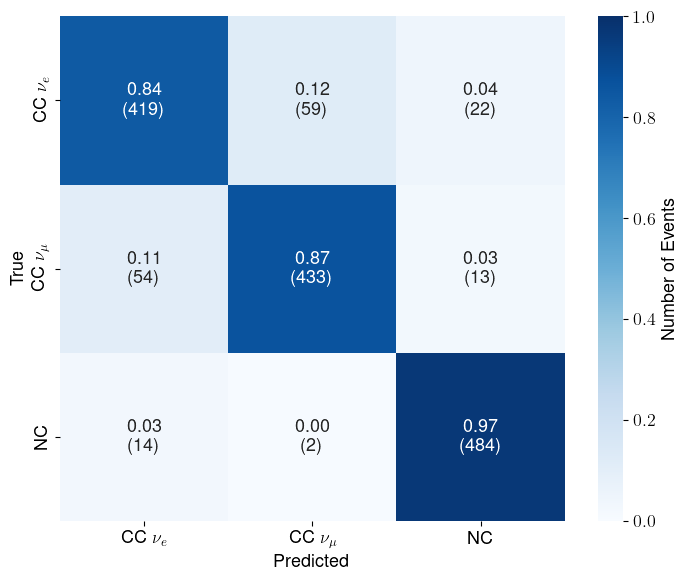

In [31]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[nu.latex_name for nu in nus]
)

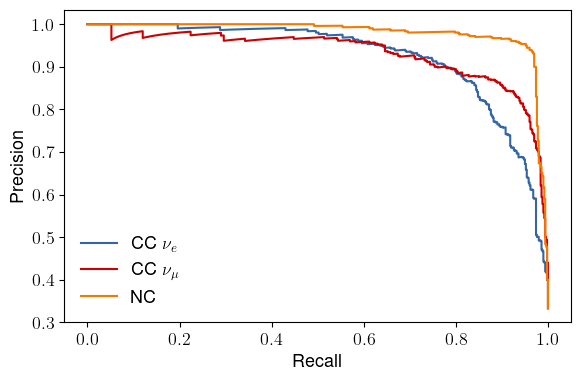

In [32]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

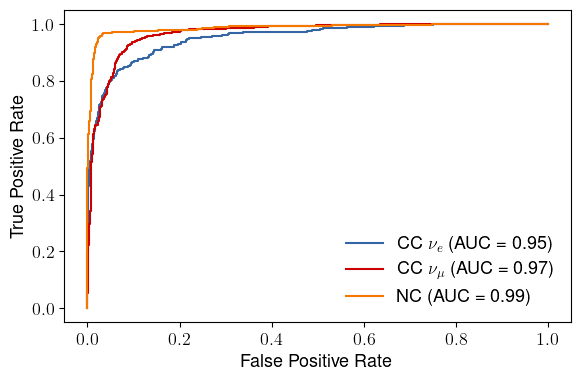

In [33]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

500.0
500.0
500.0


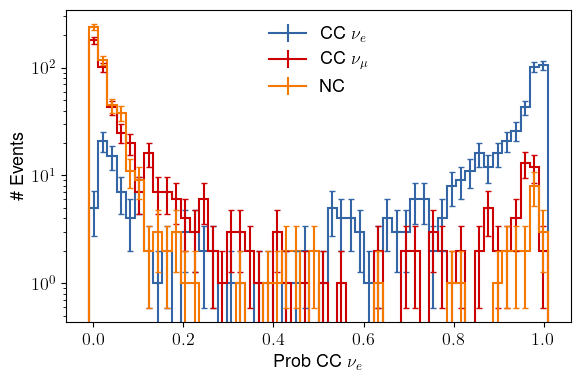

500.0
500.0
500.0


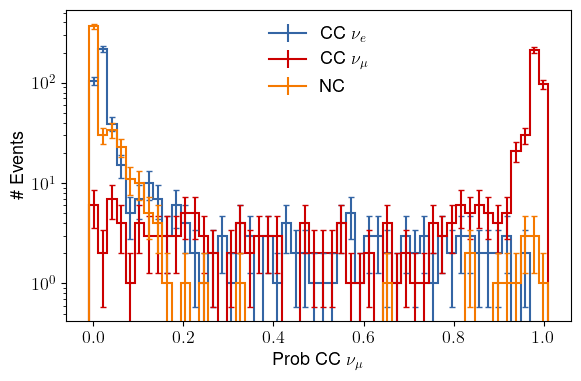

500.0
500.0
500.0


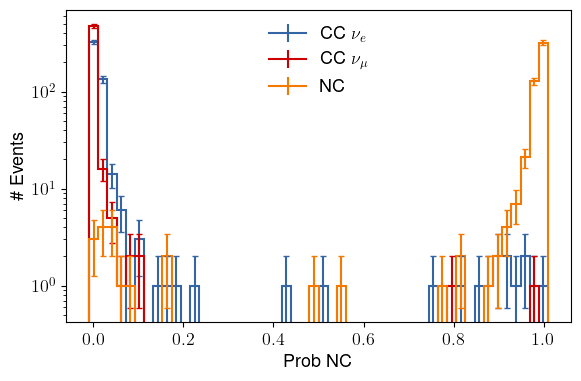

In [34]:
plot_probabilities(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    yscale="log",
)